# Road to Transformer
### Goal:
Get a working implementation of transformers from zero, to learn how it works.
### Rules:
- Base functions (cross_entropy, softmax, relu) can be AI generated for optimal implementation and clipping.
- Derivatives of base functions can be AI generated.
- Implementations are done from the math, no generation from AI here.
### Sources:
- Book: Deep Learning - Goodfellow and Al (classic)
- Book: Understanding Deep Learning - JD Prince (https://udlbook.github.io/udlbook/)
- For MLP forward: https://aiml.com/what-is-a-multilayer-perceptron-mlp/
- 3blue1brown serie on backprop: https://www.youtube.com/watch?v=tIeHLnjs5U8
- ChatGPT for base functions.
- Karparthy work (https://www.youtube.com/@AndrejKarpathy) (Not a direct source but I've watched them a year ago)

## MLP

In [6]:
# Notes: Derivate of f in respect of x, means calculating the slope of f' on point x
# Gradient calculation for a single layer is basically order: loss (outputs), activation (z), inputs (weights)
# Then: loss ∙ activation ∙ inputs

import numpy as np

LEARNING_RATE = 0.000003

def relu(x, derivative=False):
    if derivative:
        return 1 * (x > 0)
    return np.maximum(0, x)

def softmax(z, derivative=False):
    s = np.exp(z - np.max(z))
    s = s / np.sum(s)

    if derivative:
        return s * (1 - s)

    return s

def cross_entropy(predictions, targets, derivative = False):
    epsilon = 1e-15
    predictions = np.clip(predictions, epsilon, 1 - epsilon)
    if derivative:
        return -targets / predictions
    return -np.sum(targets * np.log(predictions))

class HiddenLayer:
    def __init__(self, input_dim, neuron_count, activation):
        self.weights = np.random.randn(neuron_count, input_dim) * np.sqrt(2 / input_dim)
        self.bias = np.zeros((neuron_count, 1))
        self.activation = activation

    def forward(self, inputs):
        # print("self.inputs:", inputs.shape)
        self.inputs = inputs
        self.z = self.weights @ inputs + self.bias
        self.a = self.activation(self.z)
        return self.a

    def backward(self, idelta):
        activation = self.activation(self.z, derivative=True) # Derivate activation in respect of self.z
        # Omitted calculation for the inputs, given the derivate of the inputs in respect of the weights is just the inputs.
        delta = idelta * activation
        #print("Delta:", delta.shape, "self.inputs", self.inputs.T.shape)
        self.gradient = delta @ self.inputs.T
        self.delta = delta
        x = self.weights.T @ delta
        # ^ This is weird but basically it's because all the weights of this layer is responsible for change
        # on any neuron (many-many relationship) on the next layer
        self.weightsd = x
        #print("self.weights.T", self.weights.T.shape, "delta", delta.shape, "x", x.shape)
        return x

    def update(self):
        self.weights = self.weights - LEARNING_RATE * self.gradient
        self.bias = self.bias - LEARNING_RATE * self.delta

class MLP:
    def __init__(self, input_dim, neuron_count, layer_count, output_dim):
        self.layers = []
        self.layers.append(HiddenLayer(input_dim, neuron_count, relu))
        for _ in range(layer_count):
            self.layers.append(HiddenLayer(neuron_count, neuron_count, relu))
        self.layers.append(HiddenLayer(input_dim, output_dim, softmax))

    def forward(self, inputs):
        x = np.array(inputs).reshape(-1, 1)
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, targets, outputs, loss_function):
        # delta = loss_function(outputs, targets, derivative=True) # Derivate of Loss in respect of the activation function neurons outputs
        delta = outputs - targets
        for layer in list(reversed(self.layers)):
            delta = layer.backward(delta)

    def update(self):
        for layer in reversed(self.layers):
            layer.update()

In [7]:
def mnist_dataset():
    with open("dataset/mnist_train.csv") as f:
        for line in f:
            line = [float(i) / 255.0 for i in line.strip().split(",")]
            label = int(line[0])
            data = np.array(line[1:])
            yield (label, data)

In [8]:
m = MLP(784, 784, 3, 10)
losses = []
averaged_losses = []
for label, data in mnist_dataset():
    current_m = m.forward(data)

    target_m = np.zeros((10, 1))
    target_m[label, 0] = 1.0

    loss = cross_entropy(current_m, target_m)
    # print("L:", loss)

    losses.append(loss)
    if len(losses) % 100 == 0:
        ml = np.mean(losses[-100:])
        averaged_losses.append(ml)
        print("L:", ml)

    m.backward(target_m, current_m, cross_entropy)
    m.update()

L: 3.0075814235010454
L: 3.0042483516770937
L: 3.0145607485223347
L: 2.989391136674522
L: 2.9678157641210845
L: 2.940563559181306
L: 2.9764707726088515
L: 3.019676727924865
L: 3.013032763042793
L: 2.985135467754592
L: 2.926704309083587
L: 2.9246121071431594
L: 3.0251786791389024
L: 3.100726696827374
L: 2.93534666329265
L: 2.924259011266403
L: 2.9317927178661813
L: 2.9638944856478027
L: 2.9723191953305594
L: 2.9635520645880415
L: 2.968872262908073
L: 2.973048179187751
L: 2.968509867567795
L: 2.932791150768277
L: 2.9758633394362715
L: 2.992885957584676
L: 2.929706036007062
L: 2.958749179593172
L: 2.9269017338387475
L: 2.8959094625365576
L: 2.915290606851885
L: 2.844374437317534
L: 2.8433455292813425
L: 2.9114904235668884
L: 2.870362081607884
L: 2.893386593877679
L: 2.983647438483256
L: 2.9397172741985442
L: 2.8953049770357238
L: 2.8934588825358962
L: 2.9082296272399635
L: 2.8451420705815162
L: 2.8926676483994815
L: 2.82837399370364
L: 2.8519879110266237
L: 2.914812274603804
L: 2.95003550

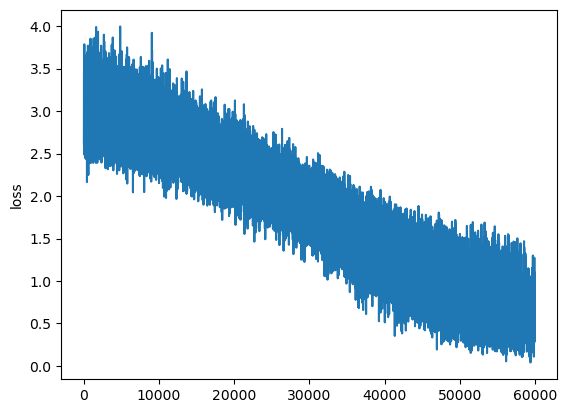

In [17]:
import matplotlib.pyplot as plt
plt.plot(losses)
# plt.plot(averaged_losses)
plt.ylabel('loss')
plt.show()

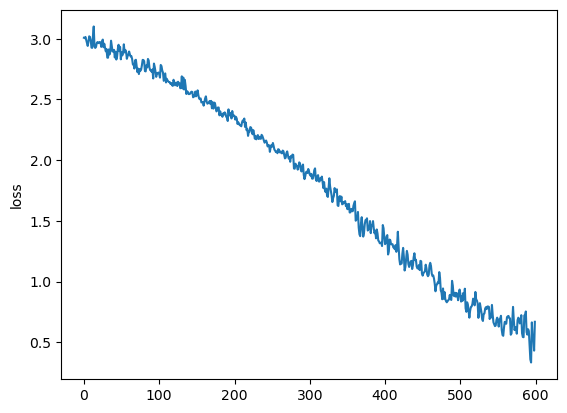

In [12]:
import matplotlib.pyplot as plt
# plt.plot(losses)
plt.plot(averaged_losses)
plt.ylabel('loss')
plt.show()

Got a working implementation of MLP on first day, not without lots of focus.

### Remarks for the future:

Column or row policy for matrices is important. It should remain constant. Easy thing to debug this is just to print `m.shape` check it.

All the base functions should be compatible / coded for the form you choose.

Depending of the notation, it can be difficult to tell difference between dot product, element wise product.
- dot product is: np.dot
- element wise product is: a @ b

backprop is:
- `delta[L] = delta[L+1] * a'(z)` # How activations influence next layer
- `gradient = delta[L] @ inputs` # How inputs influence activations
- `x = weights @ delta` # How weights influence activations
- `return x` # This is passed on to the next layer
Delta should flow from very start to very end.

Even if calculating the delta for the output layer, you still need to calculate delta relative to the weights, so pass the initial delta to the output, and then go on the next layer.

Training on MNIST can be difficult from the raw data, chatgpt recommended to scale down the grayscale value (0-255) to a float by dividing each pixel value by 255. Apparently due to some gradient vanishing issue. Not sure yet what that means, but hey the loss is going down.